In [1]:
import genetick_AI
import pandas
import numpy as np
import pandas as pd

def f_2(x):
    return ((1 - x) ** 76)/((1 - x) ** 76 + 10 * x ** 12)

def f_3(x):
    return (1-x)*(1-f_2(x)-f_5(x))

def f_4(x):
    return f_3(1 - x)

def f_5(x):
    return f_2(1 - x)

In [2]:
n,m = 10,10
matrix, perf, diff = genetick_AI.generate_rating_matrix(n,m)
df = pandas.DataFrame(matrix)
df

,0,1,2,3,4,5,6,7,8,9
0,5.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0
1,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
2,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
3,3.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,3.0,4.0
4,4.0,5.0,4.0,5.0,5.0,5.0,4.0,4.0,3.0,3.0
5,4.0,4.0,4.0,4.0,5.0,5.0,5.0,2.0,3.0,4.0
6,4.0,3.0,4.0,5.0,5.0,3.0,5.0,5.0,4.0,4.0
7,4.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,3.0,3.0
8,4.0,4.0,5.0,4.0,3.0,4.0,5.0,4.0,4.0,3.0
9,4.0,3.0,5.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0


In [3]:
def calculate_f_matrix(ratings_matrix, st_it, student_alpha=2, student_beta=2,
                       item_alpha=2, item_beta=2):
    """
    Returns a matrix of f_rating contributions (without Beta priors) for observed ratings.

    Parameters
    ----------
    ratings_matrix : np.ndarray, shape (n_students, n_items)
        Observed ratings (2..5). Unobserved entries should be 0, NaN, or a sentinel.
    st_it : np.ndarray
        Concatenated vector: first n_students entries = student parameters,
        remaining = item parameters. All values in (0,1).
    student_alpha, student_beta, item_alpha, item_beta : float
        Ignored (kept only for API compatibility). Excluded from calculation.

    Returns
    -------
    f_matrix : np.ndarray, same shape as ratings_matrix
        For each observed rating, f_rating( student_i / (student_i + item_j) ).
        Unobserved cells are set to 0.0.
    """
    # Dictionary mapping rating values to their corresponding functions
    methods = {2: f_2, 3: f_3, 4: f_4, 5: f_5}   # f_2..f_5 must be defined elsewhere

    n_students, n_items = ratings_matrix.shape
    students = st_it[:n_students]
    items = st_it[n_students:]

    # Initialize matrix with zeros (unrated cells stay 0)
    f_matrix = np.zeros_like(ratings_matrix, dtype=float)

    # Fill f_rating contributions for each observed rating value
    for rating, func in methods.items():
        mask = (ratings_matrix == rating)
        if not np.any(mask):
            continue
        rows, cols = np.where(mask)
        v1_vals = students[rows]
        v2_vals = items[cols]
        ratio = v1_vals / (v1_vals + v2_vals)
        f_vals = func(ratio)
        f_matrix[rows, cols] = f_vals

    return f_matrix
a = np.concatenate((perf,diff))
prob_m = calculate_f_matrix(matrix,a)
df = pandas.DataFrame(prob_m)
df

,0,1,2,3,4,5,6,7,8,9
0,1.566362e-17,2.526245e-10,6.250261e-02,2.292888e-07,6.551736e-01,3.898452e-10,4.418493e-02,2.078634e-21,5.813464e-15,2.219518e-16
1,3.083124e-15,2.062532e-08,6.522584e-01,1.285530e-05,3.114686e-08,3.108002e-08,5.701386e-01,6.348957e-19,8.430097e-13,3.814741e-14
2,4.357826e-14,1.862861e-07,9.088590e-01,9.615620e-05,2.779471e-07,2.773680e-07,8.768414e-01,1.126218e-17,1.018868e-11,5.029304e-13
3,6.422089e-01,8.379421e-24,6.236463e-01,5.160980e-01,4.673972e-01,4.673806e-01,1.936535e-12,3.112770e-01,6.074120e-01,3.729716e-01
4,4.766129e-01,9.227544e-15,7.303295e-01,1.970225e-11,1.506359e-14,1.502516e-14,7.275570e-01,4.248711e-01,4.862782e-01,5.070351e-01
5,3.190956e-01,4.215704e-01,5.822672e-01,4.728885e-01,4.114874e-27,4.101493e-27,2.891811e-15,1.214490e-05,6.478070e-01,3.334868e-01
6,3.298247e-01,5.664488e-01,5.941240e-01,3.827040e-22,4.406777e-26,5.633273e-01,1.910923e-14,2.276491e-41,3.634410e-01,3.444551e-01
7,4.571766e-01,4.355445e-16,2.815490e-06,1.192479e-12,7.221592e-16,7.202581e-16,1.836988e-06,5.940916e-01,5.057989e-01,5.265350e-01
8,3.974611e-01,5.063862e-01,1.157886e-09,5.580677e-01,4.904230e-01,5.095603e-01,7.206252e-10,3.485891e-01,4.335118e-01,5.867583e-01
9,4.816359e-01,4.089974e-01,5.168937e-05,3.999761e-11,3.245342e-14,3.237129e-14,7.315168e-01,4.297966e-01,5.187482e-01,4.979962e-01


In [4]:
rm = pandas.DataFrame(matrix)
out = []
for column in rm.columns:
    print(rm[column].value_counts())

0
4.0    6
5.0    3
3.0    1
Name: count, dtype: int64
1
5.0    6
4.0    2
3.0    2
Name: count, dtype: int64
2
5.0    6
4.0    4
Name: count, dtype: int64
3
5.0    7
4.0    3
Name: count, dtype: int64
4
5.0    7
4.0    2
3.0    1
Name: count, dtype: int64
5
5.0    7
4.0    2
3.0    1
Name: count, dtype: int64
6
5.0    8
4.0    2
Name: count, dtype: int64
7
5.0    4
4.0    4
2.0    1
3.0    1
Name: count, dtype: int64
8
3.0    4
5.0    3
4.0    3
Name: count, dtype: int64
9
4.0    4
5.0    3
3.0    3
Name: count, dtype: int64


In [5]:
del a
res = genetick_AI.try_find_opt(matrix)

In [6]:
# print(pandas.Series(res[:n]),'\n',pandas.Series(res[n:]))
# print(pandas.Series(perf),'\n', pandas.Series(diff))
df1 = pandas.DataFrame((pandas.Series(res[:n]),pandas.Series(perf)))
df2 = pandas.DataFrame((pandas.Series(res[n:]),pandas.Series(diff)))
df1

,0,1,2,3,4,5,6,7,8,9
0,0.731620,0.808258,0.790018,0.285285,0.368437,0.271816,0.416511,0.455302,0.218508,0.395606
1,0.761013,0.868548,0.930582,0.351495,0.574524,0.295665,0.310499,0.531363,0.416174,0.586205


In [7]:
df2

,0,1,2,3,4,5,6,7,8,9
0,0.512604,0.381597,0.278243,0.242348,0.262559,0.274438,0.202041,0.455305,0.579472,0.541132
1,0.630907,0.405677,0.212118,0.329567,0.400531,0.400558,0.215123,0.777708,0.543832,0.590922


In [8]:
print(np.abs(perf-res[:n]),'\n',np.abs(diff-res[n:]))
print(max(np.abs(perf-res[:n])),max(np.abs(diff-res[n:])))

[0.02939353 0.06028965 0.14056359 0.06620986 0.20608745 0.02384949
 0.10601212 0.07606074 0.19766572 0.19059896] 
 [0.1183029  0.02407981 0.06612557 0.08721907 0.13797178 0.12611948
 0.01308172 0.32240291 0.03563909 0.04979059]
0.2060874530898883 0.3224029107026689


In [9]:
prob_m_ap = calculate_f_matrix(matrix,np.array(res))
df1 = pandas.DataFrame(prob_m_ap)
df1

,0,1,2,3,4,5,6,7,8,9
0,1.243902e-14,5.312623e-10,1.201698e-05,6.386706e-04,7.358550e-01,1.804960e-05,7.815545e-02,1.054351e-12,1.001825e-16,1.522169e-15
1,5.266565e-13,1.455149e-08,2.161135e-04,9.641853e-03,1.098526e-03,3.190792e-04,5.136520e-01,3.732339e-11,5.127490e-15,7.004456e-14
2,2.262793e-13,6.900952e-09,1.126991e-04,5.242013e-03,5.823445e-04,1.670421e-04,3.742349e-01,1.670141e-11,2.109967e-15,2.953013e-14
3,6.424505e-01,7.634353e-27,5.062479e-01,5.406881e-01,5.207409e-01,5.096892e-01,8.230942e-15,3.852132e-01,6.700980e-01,3.452071e-01
4,4.181834e-01,1.145868e-21,5.697360e-01,1.359750e-13,6.473698e-15,1.153845e-15,6.458388e-01,4.472724e-01,6.113160e-01,5.949323e-01
5,3.465181e-01,4.159937e-01,4.941576e-01,5.286559e-01,2.465971e-20,3.550376e-21,1.253631e-15,4.751799e-12,6.807003e-01,3.343584e-01
6,4.482879e-01,4.781271e-01,5.995087e-01,1.190202e-11,6.581894e-13,3.971901e-01,6.001460e-09,1.011163e-22,4.181912e-01,4.349338e-01
7,4.703987e-01,1.000939e-17,2.043389e-12,2.658726e-10,1.634702e-11,3.362410e-12,1.063617e-07,5.000015e-01,5.599985e-01,5.430685e-01
8,2.988710e-01,3.641166e-01,8.195667e-26,4.741355e-01,5.457844e-01,4.432699e-01,1.621833e-19,3.242865e-01,2.738228e-01,7.123512e-01
9,4.355884e-01,4.909879e-01,1.073669e-14,1.871425e-12,9.723149e-14,1.819747e-14,6.619390e-01,4.649207e-01,4.057174e-01,4.223231e-01


In [10]:
df

,0,1,2,3,4,5,6,7,8,9
0,1.566362e-17,2.526245e-10,6.250261e-02,2.292888e-07,6.551736e-01,3.898452e-10,4.418493e-02,2.078634e-21,5.813464e-15,2.219518e-16
1,3.083124e-15,2.062532e-08,6.522584e-01,1.285530e-05,3.114686e-08,3.108002e-08,5.701386e-01,6.348957e-19,8.430097e-13,3.814741e-14
2,4.357826e-14,1.862861e-07,9.088590e-01,9.615620e-05,2.779471e-07,2.773680e-07,8.768414e-01,1.126218e-17,1.018868e-11,5.029304e-13
3,6.422089e-01,8.379421e-24,6.236463e-01,5.160980e-01,4.673972e-01,4.673806e-01,1.936535e-12,3.112770e-01,6.074120e-01,3.729716e-01
4,4.766129e-01,9.227544e-15,7.303295e-01,1.970225e-11,1.506359e-14,1.502516e-14,7.275570e-01,4.248711e-01,4.862782e-01,5.070351e-01
5,3.190956e-01,4.215704e-01,5.822672e-01,4.728885e-01,4.114874e-27,4.101493e-27,2.891811e-15,1.214490e-05,6.478070e-01,3.334868e-01
6,3.298247e-01,5.664488e-01,5.941240e-01,3.827040e-22,4.406777e-26,5.633273e-01,1.910923e-14,2.276491e-41,3.634410e-01,3.444551e-01
7,4.571766e-01,4.355445e-16,2.815490e-06,1.192479e-12,7.221592e-16,7.202581e-16,1.836988e-06,5.940916e-01,5.057989e-01,5.265350e-01
8,3.974611e-01,5.063862e-01,1.157886e-09,5.580677e-01,4.904230e-01,5.095603e-01,7.206252e-10,3.485891e-01,4.335118e-01,5.867583e-01
9,4.816359e-01,4.089974e-01,5.168937e-05,3.999761e-11,3.245342e-14,3.237129e-14,7.315168e-01,4.297966e-01,5.187482e-01,4.979962e-01


In [11]:
print(df.prod().prod(),df1.prod().prod(),(df1/df).prod().prod(),df1.prod().prod()/df.prod().prod())

0.0 0.0 5.122038926227183e+37 nan


C:\Users\user\AppData\Local\Temp\ipykernel_12084\736052553.py:1: RuntimeWarning: invalid value encountered in scalar divide
  print(df.prod().prod(),df1.prod().prod(),(df1/df).prod().prod(),df1.prod().prod()/df.prod().prod())


In [12]:
import Parser_lib

In [13]:
sm1,sm2 = Parser_lib.parse('Grades.xls')

In [14]:
res1 = genetick_AI.try_find_opt(sm1)
res2 = genetick_AI.try_find_opt(sm2)

In [15]:
n_students, n_items = sm1.shape
res1, res2 = np.array(res1), np.array(res2)

In [16]:
print(np.abs(res1[:n_students]-res2[:n_students]))

[0.02506641 0.59244476 0.48899314 0.02538574 0.50692447 0.01144592
 0.48895015 0.25679683 0.1816577  0.17017295 0.62610543 0.22499627
 0.11703638 0.14065845 0.26961971 0.3371698  0.27540757 0.54871157
 0.45852023 0.13218566 0.32961853 0.46399192 0.256792   0.15485319
 0.26914445 0.05786379 0.22605001 0.15959691 0.42399181 0.36019858
 0.07029479 0.1292786  0.32509545 0.41015083 0.06288423 0.50280184
 0.29915724 0.25779582 0.58211704 0.30771627 0.00493813 0.27867498
 0.36533392 0.3598412  0.04103672 0.81700128 0.56475804 0.1008651
 0.23591293 0.35719911 0.08852654 0.18803989 0.08210495 0.56244826
 0.30673034 0.52148768 0.26134598 0.51133515 0.18432726 0.7817777
 0.47099842 0.03875093 0.19671652 0.03736519 0.03066334 0.12637261
 0.11637224 0.21928096 0.5070665  0.68389265 0.05242479 0.21179146
 0.23196383 0.20670424 0.01166067 0.32895609 0.00148878 0.77600194
 0.13859185 0.00515467 0.59008695 0.37679558 0.57979859 0.05419581
 0.16950813 0.1804115  0.32756697 0.193999   0.31567549 0.241857

In [17]:
print(res1[n_students:], res2[n_students:])

[0.10821808 0.05786417 0.68460246 0.64276767 0.66080036 0.71110869] [0.06836453 0.10821808 0.0726913  0.7278671  0.65807648 0.66080036
 0.06159051 0.55009461 0.69217261 0.52611993]


In [18]:
df1 = pandas.DataFrame(sm1)
df1

,0,1,2,3,4,5
0,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,NaN,5.0,3.0,5.0,5.0
2,5.0,5.0,5.0,4.0,3.0,5.0
3,4.0,5.0,5.0,5.0,5.0,5.0
4,5.0,5.0,4.0,4.0,3.0,3.0
...,...,...,...,...,...,...
133,4.0,5.0,5.0,4.0,5.0,3.0
134,5.0,NaN,5.0,5.0,5.0,5.0
135,NaN,NaN,NaN,NaN,NaN,NaN
136,4.0,4.0,NaN,NaN,NaN,NaN


In [19]:
df2 = pandas.DataFrame(sm2)
df2

,0,1,2,3,4,5,6,7,8,9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,5.0,5.0,5.0,3.0,5.0,NaN,4.0,5.0,3.0
2,5.0,5.0,5.0,4.0,5.0,3.0,5.0,4.0,4.0,5.0
3,4.0,4.0,5.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0
4,4.0,5.0,5.0,3.0,3.0,3.0,5.0,3.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...
133,4.0,4.0,4.0,4.0,5.0,5.0,4.0,5.0,4.0,4.0
134,4.0,5.0,NaN,5.0,5.0,5.0,NaN,5.0,5.0,NaN
135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
import matplotlib.pyplot as plt

(array([ 4.,  4., 10.,  5.,  7.,  9.,  8.,  6., 10., 13.,  7., 10.,  7.,
         4.,  5.,  7., 12.,  4.,  4.,  2.]),
 array([0.07480877, 0.11843963, 0.16207049, 0.20570135, 0.2493322 ,
        0.29296306, 0.33659392, 0.38022478, 0.42385564, 0.4674865 ,
        0.51111736, 0.55474822, 0.59837908, 0.64200994, 0.6856408 ,
        0.72927166, 0.77290252, 0.81653338, 0.86016424, 0.9037951 ,
        0.94742596]),
 <BarContainer object of 20 artists>)

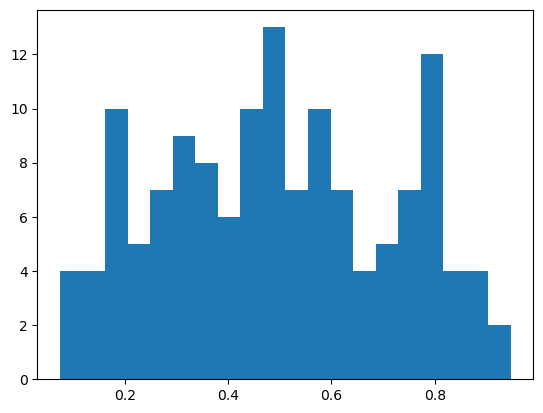

In [21]:
plt.hist(res1[:n_students],bins=20)

(array([ 4.,  2.,  7.,  7.,  9., 12.,  6., 13.,  8.,  5.,  5.,  7.,  6.,
         9., 10.,  9.,  7.,  9.,  2.,  1.]),
 array([0.04395578, 0.08970831, 0.13546084, 0.18121338, 0.22696591,
        0.27271844, 0.31847098, 0.36422351, 0.40997604, 0.45572857,
        0.50148111, 0.54723364, 0.59298617, 0.6387387 , 0.68449124,
        0.73024377, 0.7759963 , 0.82174883, 0.86750137, 0.9132539 ,
        0.95900643]),
 <BarContainer object of 20 artists>)

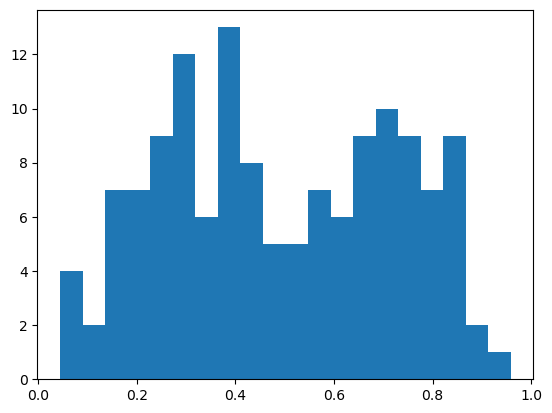

In [22]:
plt.hist(res2[:n_students],bins=20)

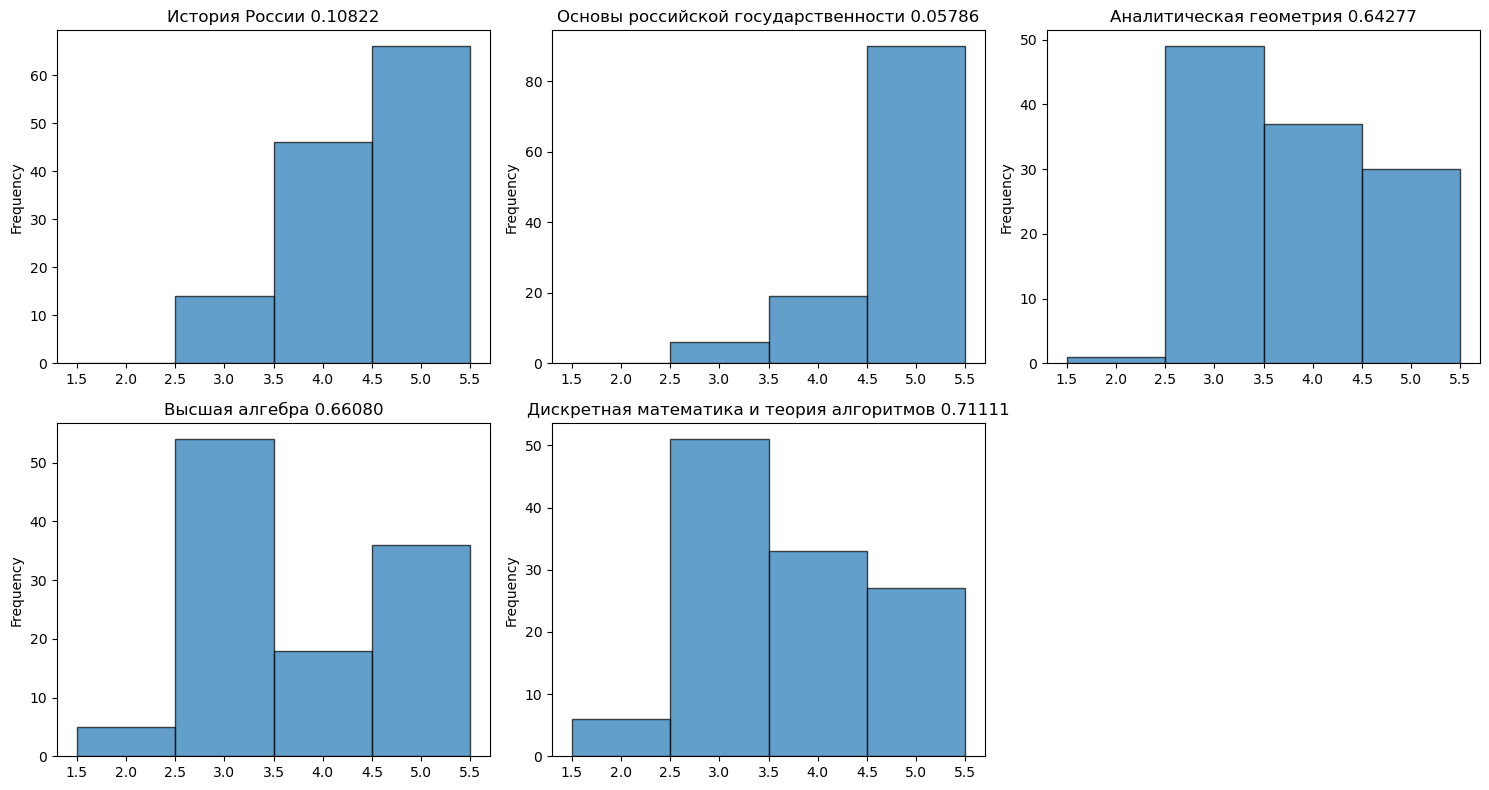

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# Sample DataFrame (replace with your own)
df = df1.drop(df1.columns[2],axis=1)

bins = [1.5, 2.5, 3.5, 4.5, 5.5]

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
n_cols = len(numeric_cols)

# Define grid layout (e.g., up to 3 columns per row)
cols_per_row = 3
rows = math.ceil(n_cols / cols_per_row)

# Create subplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, rows * 4))
axes = axes.flatten()  # Flatten in case of multiple rows

# Hide unused subplots if any
for i in range(n_cols, len(axes)):
    axes[i].set_visible(False)

# Plot histogram for each numeric column
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=bins, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_ylabel('Frequency')

axes[0].set_title(f'История России {res1[n_students:][0]:.5f}')
axes[1].set_title(f'Основы российской государственности {res1[n_students:][1]:.5f}')
axes[2].set_title(f'Аналитическая геометрия {res1[n_students:][3]:.5f}')
axes[3].set_title(f'Высшая алгебра {res1[n_students:][4]:.5f}')
axes[4].set_title(f'Дискретная математика и теория алгоритмов {res1[n_students:][5]:.5f}')
axes[5].set_title(f'Математический анализ {res1[n_students:][5]:.5f}')

plt.tight_layout()

# Save the figure as a picture (change filename/format as needed)
plt.savefig('histograms.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
df = pd.DataFrame(calculate_f_matrix(sm1,res1))
df

,0,1,2,3,4,5
0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.000202,0.000000e+00,5.615644e-38,6.720920e-01,4.023593e-37,6.652666e-39
2,0.999856,1.000000e+00,1.831114e-22,4.967763e-01,5.101395e-01,3.249244e-23
3,0.000001,1.000000e+00,3.335721e-18,4.454219e-17,1.439599e-17,6.789552e-19
4,0.999998,1.000000e+00,5.340571e-01,5.497089e-01,4.571488e-01,4.754067e-01
...,...,...,...,...,...,...
133,0.677240,3.954413e-01,4.105421e-46,2.610230e-01,3.412626e-45,7.566302e-01
134,0.999498,0.000000e+00,1.300402e-23,2.310914e-22,6.588820e-23,2.228026e-24
135,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
136,0.008448,2.481497e-08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [25]:
df1

,0,1,2,3,4,5
0,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,NaN,5.0,3.0,5.0,5.0
2,5.0,5.0,5.0,4.0,3.0,5.0
3,4.0,5.0,5.0,5.0,5.0,5.0
4,5.0,5.0,4.0,4.0,3.0,3.0
...,...,...,...,...,...,...
133,4.0,5.0,5.0,4.0,5.0,3.0
134,5.0,NaN,5.0,5.0,5.0,5.0
135,NaN,NaN,NaN,NaN,NaN,NaN
136,4.0,4.0,NaN,NaN,NaN,NaN
